This notebook recreates plots from Figure 5 using the DM/DAMN signature and bulk RNA-seq results from transcription factor overexpression in iPSC-derived motor neurons.

## Setup

In [1]:
renv::load('/oak/stanford/groups/agitler/Shared/Shared_Jupyter_Notebook_Analysis/4.1.1-OG-Multiome/')

# Load packages
suppressPackageStartupMessages({
  library(dplyr)
  library(stringr)
  library(fgsea)
  library(tibble)
  library(ggplot2)
  library(ggrepel)
  library(ggrastr)
  library(colorspace)
  library(forcats)
})

# Directory 
save_dir <- "/oak/stanford/groups/agitler/Shared/SOD1_Paper/iMN_TF_OE/"

## Load DAMN signature and TF overexpression DESeq2 results

In [2]:
damn_human_symbols <- read.csv("/oak/stanford/groups/agitler/Shared/SOD1_Paper/Biogen_data/mouse_damn_mapped_with_stats.csv")

damn_human_symbols_filtered <- damn_human_symbols %>%
  dplyr::filter(
    !is.na(hgnc_symbol),
    hgnc_symbol != "",
    if ("display_symbol" %in% colnames(.)) display_symbol != "" else TRUE,
    if ("description" %in% colnames(.))
      !str_detect(tolower(description), "readthrough")
    else TRUE
  ) %>%
  group_by(hgnc_symbol) %>%
  dplyr::filter(n() == 1) %>%   
  ungroup()

damn_up <- dplyr::filter(damn_human_symbols_filtered, padj < 0.01 & log2FoldChange > 0)
damn_down <- dplyr::filter(damn_human_symbols_filtered, padj < 0.01 & log2FoldChange < 0)

In [3]:
atf3 <- read.csv(paste0(save_dir, "Atf3_vs_mCherry_results.csv"))
creb3 <- read.csv(paste0(save_dir, "Creb3_vs_mCherry_results.csv"))

# Flip the direction so that positive = upregulated in ATF3 OE
atf3_fixed <- atf3 %>%
  mutate(
    log2FoldChange = -log2FoldChange,
    stat = -stat
  ) %>% filter(!is.na(padj))

creb3_fixed <- creb3 %>% filter(!is.na(padj))

## Volcano plots

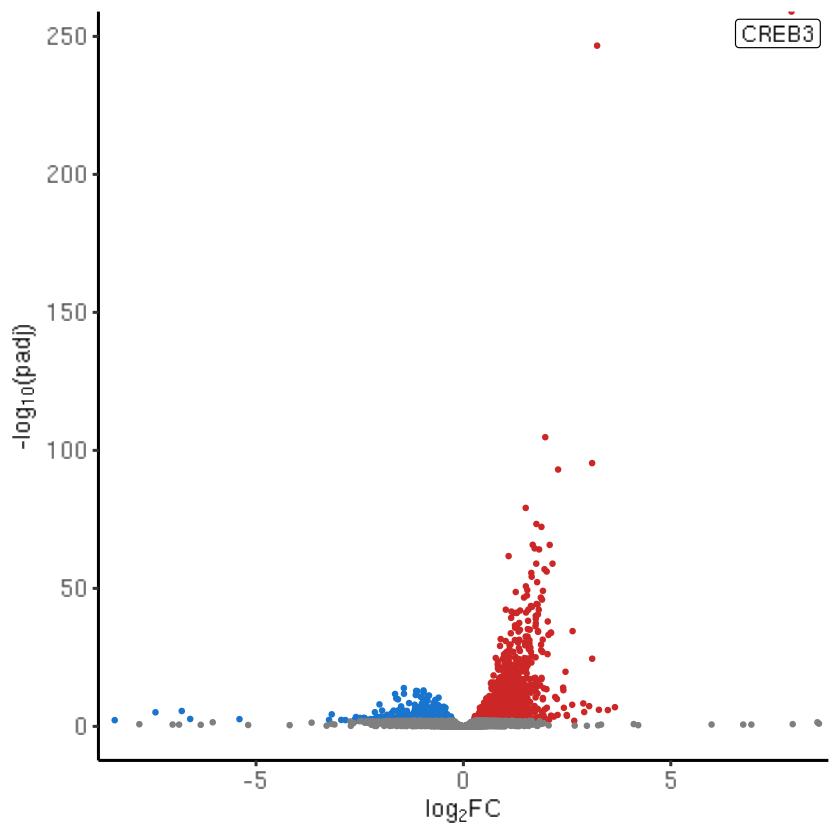

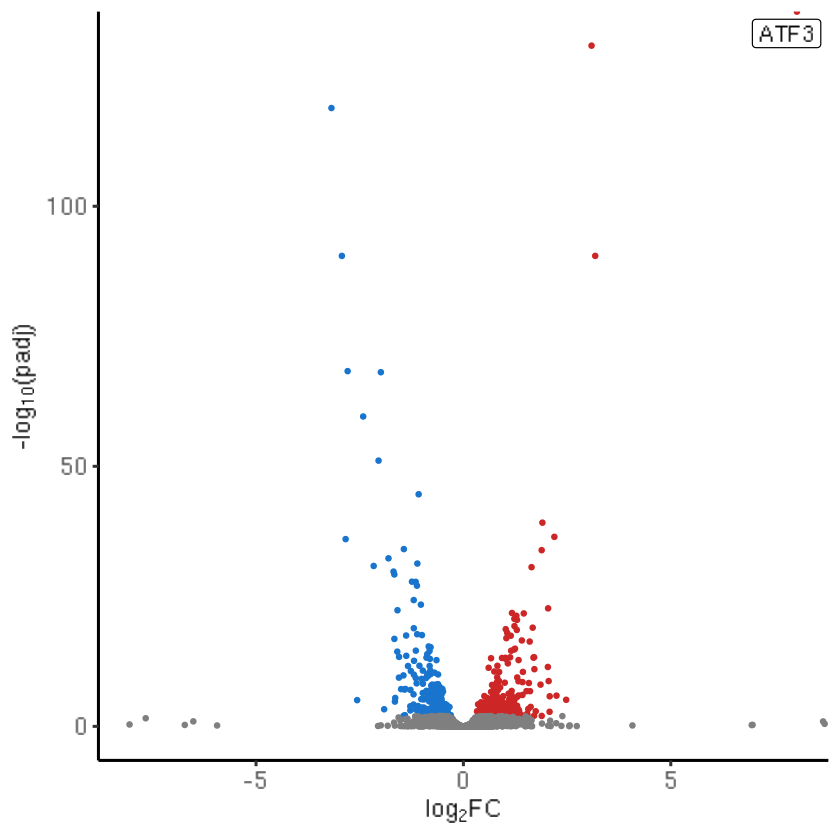

In [4]:
make_volcano_plot <- function(data, labeled_pts=0, labeled_genes=NULL, p_val_cutoff=0.01, x_clip=0) {
  data <- data %>%
    mutate(
      Expression = case_when(
        log2FoldChange >= 0 & padj <= p_val_cutoff ~ "Up-regulated",
        log2FoldChange <= 0 & padj <= p_val_cutoff ~ "Down-regulated",
        TRUE ~ "Unchanged"
      )
    )

  top <- labeled_pts
  top_genes <- bind_rows(
    data %>%
      filter(Expression == 'Up-regulated') %>%
      arrange(padj, desc(abs(log2FoldChange))) %>%
      head(top),
    data %>%
      filter(Expression == 'Down-regulated') %>%
      arrange(padj, desc(abs(log2FoldChange))) %>%
      head(top),
    data %>%
      filter(!is.null(labeled_genes), gene %in% labeled_genes)
  ) %>%
    distinct(gene, .keep_all = TRUE)

  p1 <- ggplot(data, aes(log2FoldChange, -log10(padj))) +
    geom_point(aes(color = Expression), size = 4/5) +
    geom_label_repel(
      data = top_genes,
      mapping = aes(log2FoldChange, -log10(padj), label = gene),
      size = 4.5,
      force = 0.01
    ) +
    coord_cartesian(xlim = c(-x_clip, x_clip)) +
    xlab(expression("log"[2]*"FC")) +
    ylab(expression("-log"[10]*"(padj)")) +
    scale_color_manual(values = c("dodgerblue3", "gray50", "firebrick3")) +
    theme_classic(base_size = 14) +
    theme(
      legend.position = "none",   # <-- removes legend
      axis.text       = element_text(size = 14),
      axis.title      = element_text(size = 14),
      plot.title      = element_text(size = 14, hjust = 0.5),
      strip.text      = element_text(size = 14)
    )

  return(p1)
}

creb3_fixed$gene <- creb3_fixed$X
atf3_fixed$gene <- atf3_fixed$X

p_creb3_volcano <- make_volcano_plot(
  creb3_fixed,
  labeled_genes = c("CREB3"),
  x_clip = 8
)
p_creb3_volcano

p_atf3_volcano <- make_volcano_plot(
  atf3_fixed,
  labeled_genes = c("ATF3"),
  x_clip = 8
)
p_atf3_volcano

## DAMN gene sets and GSEA

In [5]:
# Build DAMN pathways
get_symbols <- function(df, symbol_col = "hgnc_symbol") {
  df %>%
    pull(.data[[symbol_col]]) %>%
    as.character() %>%
    unique() %>%
    .[!is.na(.) & . != ""]
}

pathways <- list(
  DAMN_up   = get_symbols(damn_up,   "hgnc_symbol"),
  DAMN_down = get_symbols(damn_down, "hgnc_symbol")
)

# Make ranked vector from DESeq2 results 
make_ranks_deseq2 <- function(res_df, gene_col = "X", stat_col = "stat", jitter_sd = 1e-7, seed = 1) {
  stopifnot(gene_col %in% colnames(res_df), stat_col %in% colnames(res_df))

  df <- res_df %>%
    transmute(
      gene  = as.character(.data[[gene_col]]),
      score = as.numeric(.data[[stat_col]])
    ) %>%
    filter(!is.na(gene), gene != "", !is.na(score), is.finite(score)) %>%
    group_by(gene) %>%
    # if duplicated gene symbols exist, keep the strongest evidence row
    slice_max(order_by = abs(score), n = 1, with_ties = FALSE) %>%
    ungroup()

  ranks <- df$score
  names(ranks) <- df$gene
  ranks <- sort(ranks, decreasing = TRUE)

  # Break ties deterministically with tiny jitter 
  set.seed(seed)
  ranks <- ranks + rnorm(length(ranks), mean = 0, sd = jitter_sd)
  ranks
}

# Run fgseaMultilevel (no nperm) 
run_fgsea_multilevel <- function(ranks, pathways, minSize = 15, maxSize = 5000) {
  universe <- names(ranks)
  pw <- lapply(pathways, function(gs) intersect(gs, universe))

  fgseaMultilevel(
    pathways = pw,
    stats    = ranks,
    minSize  = minSize,
    maxSize  = maxSize
  ) %>%
    as_tibble() %>%
    arrange(padj)
}

# Create ranks
r_atf3  <- make_ranks_deseq2(atf3_fixed, gene_col = "X", stat_col = "stat")
r_creb3 <- make_ranks_deseq2(creb3_fixed,      gene_col = "X", stat_col = "stat")

# Run GSEA 
g_atf3  <- run_fgsea_multilevel(r_atf3,  pathways)
g_creb3 <- run_fgsea_multilevel(r_creb3, pathways)

# Combine results 
gsea_all <- bind_rows(
  g_atf3  %>% mutate(contrast = "ATF3_OE_vs_Ctrl"),
  g_creb3 %>% mutate(contrast = "CREB3_OE_vs_Ctrl")
) %>%
  select(contrast, pathway, size, NES, pval, padj) %>%
  arrange(contrast, padj)

gsea_all

contrast,pathway,size,NES,pval,padj
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
ATF3_OE_vs_Ctrl,DAMN_down,1768,-1.6625446,8.997216e-15,1.799443e-14
ATF3_OE_vs_Ctrl,DAMN_up,1727,1.2843084,4.473358e-04,4.473358e-04
CREB3_OE_vs_Ctrl,DAMN_up,1799,1.5989408,2.693115e-25,5.386230e-25
CREB3_OE_vs_Ctrl,DAMN_down,1847,0.8032532,9.990010e-01,9.990010e-01


## GSEA panel plotting

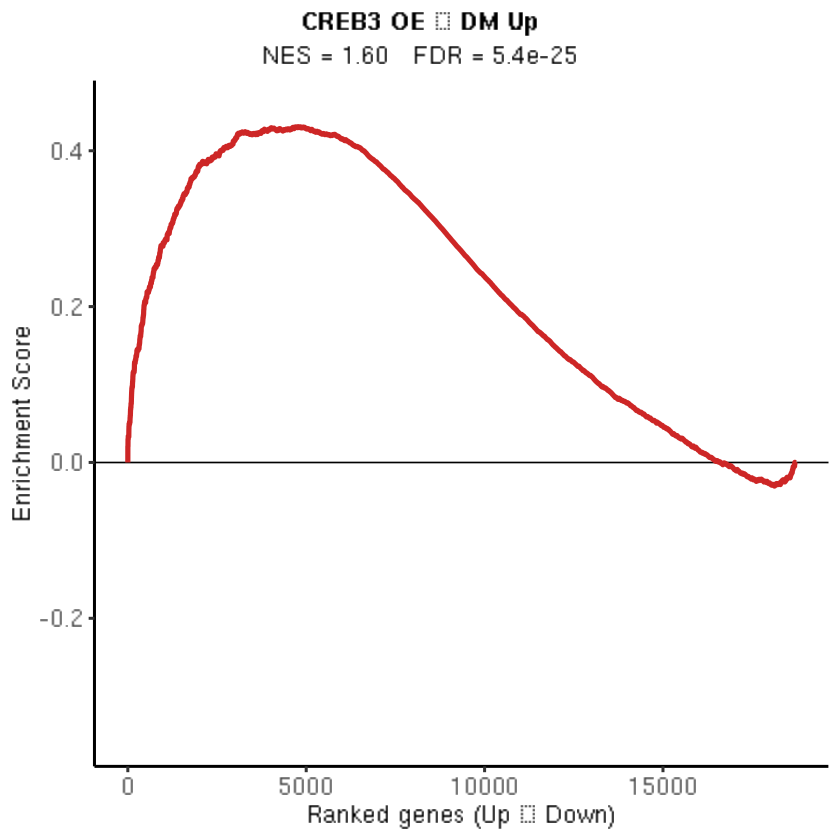

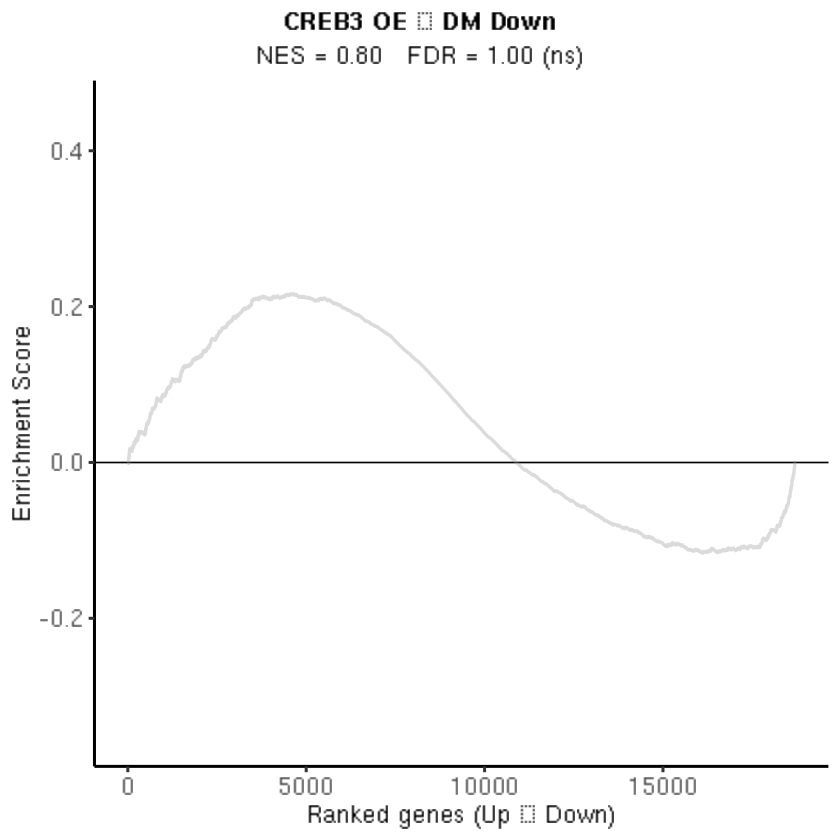

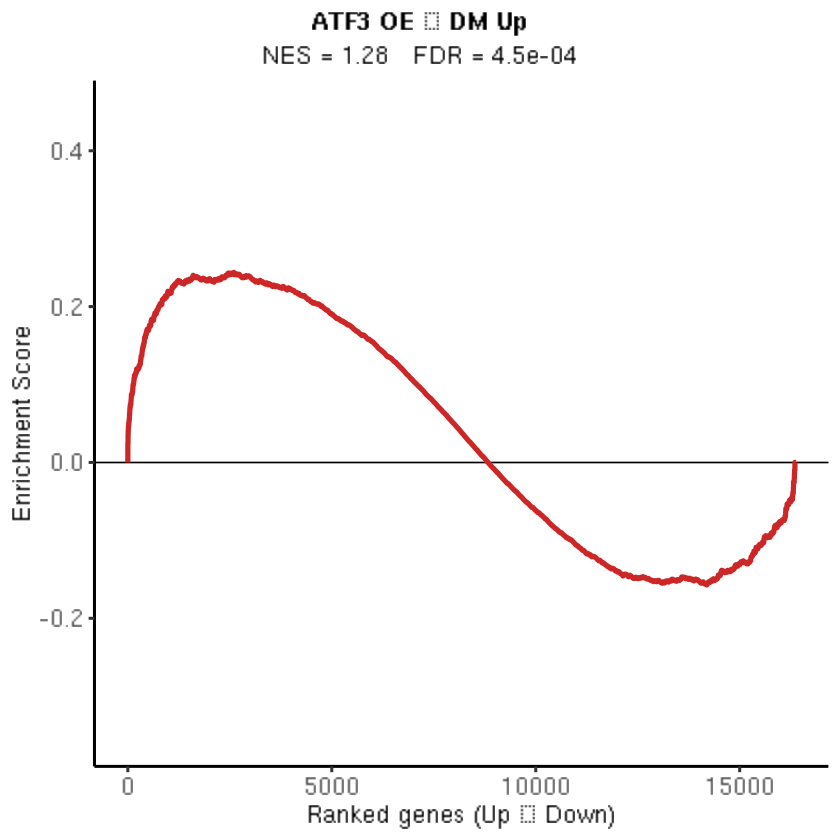

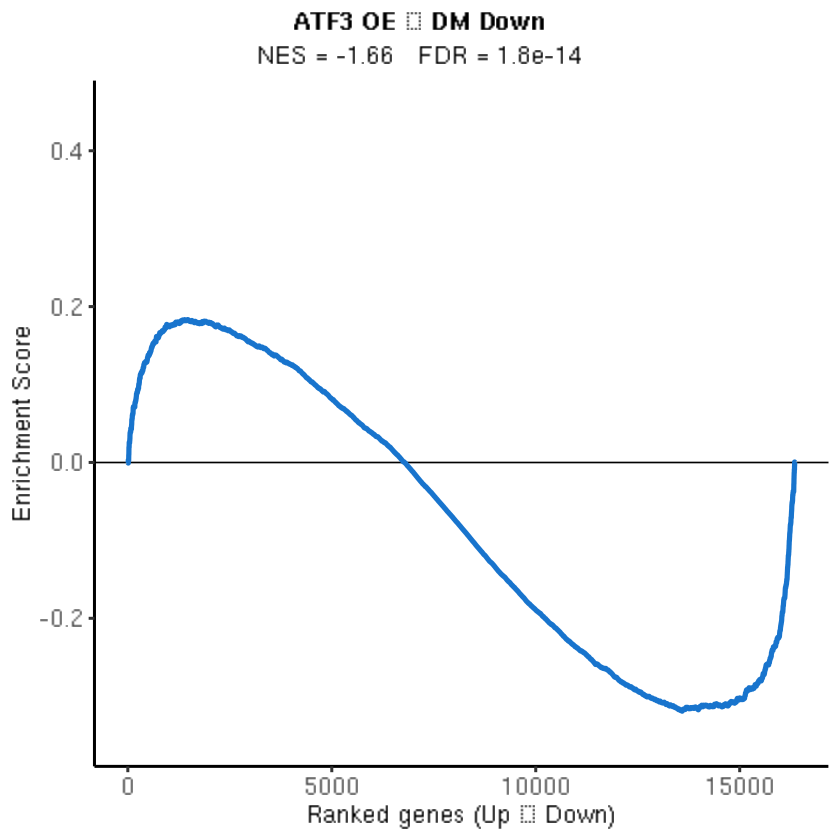

In [6]:
# =========================
# GSEA panel plotting
# =========================

fmt_fdr <- function(fdr) {
  if (is.na(fdr)) return("NA")
  if (fdr >= 0.995) return("1.00")
  if (fdr < 1e-3) return(format(fdr, scientific = TRUE, digits = 2))
  formatC(fdr, format = "f", digits = 3)
}

make_gsea_panel <- function(ranks, pathways, g_tbl, pathway_name,
                            title, fdr_cutoff = 0.05,
                            ylims = c(-0.35, 0.45)) {
  
  gs <- intersect(pathways[[pathway_name]], names(ranks))
  
  row <- g_tbl %>%
    filter(pathway == pathway_name) %>%
    slice(1)
  
  if (nrow(row) == 0) {
    stop("Pathway not found in g_tbl: ", pathway_name)
  }
  
  is_sig <- !is.na(row$padj) && row$padj < fdr_cutoff
  
  curve_col <- if (!is_sig) {
    "grey60"
  } else if (pathway_name == "DAMN_up") {
    "firebrick3"
  } else {
    "dodgerblue3"
  }
  
  subtitle <- sprintf(
    "NES = %.2f   FDR = %s%s",
    row$NES,
    fmt_fdr(row$padj),
    if (!is_sig) " (ns)" else ""
  )
  
  # Use fgsea to calculate the enrichment curve, but remove its default layers
  p0 <- plotEnrichment(gs, ranks)
  df_line <- ggplot_build(p0)$data[[1]]
  p0$layers <- list()
  
  p0 +
    geom_hline(yintercept = 0, linewidth = 0.35) +
    geom_line(
      data = df_line,
      aes(x = x, y = y),
      inherit.aes = FALSE,
      linewidth = if (is_sig) 1.1 else 0.7,
      colour = curve_col,
      alpha = if (is_sig) 1 else 0.35
    ) +
    coord_cartesian(ylim = ylims) +
    labs(
      title = title,
      subtitle = subtitle,
      x = "Ranked genes (Up – Down)",
      y = "Enrichment Score"
    ) +
    theme_classic(base_size = 14) +
    theme(
      plot.title.position = "plot",
      plot.title = element_text(face = "bold", hjust = 0.5, size = 14),
      plot.subtitle = element_text(hjust = 0.5, size = 14),
      axis.title = element_text(size = 14),
      axis.text = element_text(size = 14)
    )
}

# Build Figure 5 GSEA panels
p_atf3_up <- make_gsea_panel(
  r_atf3, pathways, g_atf3,
  pathway_name = "DAMN_up",
  title = "ATF3 OE – DM Up"
)

p_atf3_down <- make_gsea_panel(
  r_atf3, pathways, g_atf3,
  pathway_name = "DAMN_down",
  title = "ATF3 OE – DM Down"
)

p_creb3_up <- make_gsea_panel(
  r_creb3, pathways, g_creb3,
  pathway_name = "DAMN_up",
  title = "CREB3 OE – DM Up"
)

p_creb3_down <- make_gsea_panel(
  r_creb3, pathways, g_creb3,
  pathway_name = "DAMN_down",
  title = "CREB3 OE – DM Down"
)

# Print CREB3 and ATF3 plots
p_creb3_up
p_creb3_down
p_atf3_up
p_atf3_down

plots <- list(
  CREB3_OE_DAMN_Up   = p_creb3_up,
  CREB3_OE_DAMN_Down = p_creb3_down,
  ATF3_OE_DAMN_Up    = p_atf3_up,
  ATF3_OE_DAMN_Down  = p_atf3_down
)

## Leading-edge table generation

In [7]:
# Helper: extract leading-edge genes for one pathway from an fgsea result table
get_leading_edge <- function(gsea_tbl, pathway_name) {
  le <- gsea_tbl %>%
    dplyr::filter(pathway == pathway_name) %>%
    dplyr::pull(leadingEdge)

  if (length(le) == 0) stop("Pathway not found: ", pathway_name)
  unique(unlist(le))
}

# Get leading-edge genes 
le_atf3_up   <- get_leading_edge(g_atf3,  "DAMN_up")
le_atf3_down <- get_leading_edge(g_atf3,  "DAMN_down")
le_creb3_up  <- get_leading_edge(g_creb3, "DAMN_up")

# Store as a named list 
leading_edges <- list(
  ATF3_DAMN_up   = le_atf3_up,
  ATF3_DAMN_down = le_atf3_down,
  CREB3_DAMN_up  = le_creb3_up
)

# Quick counts
sapply(leading_edges, length)

# Put in a tibble 
leading_edges_tbl <- dplyr::bind_rows(
  tibble(contrast = "ATF3",  pathway = "DAMN_up",   gene = le_atf3_up),
  tibble(contrast = "ATF3",  pathway = "DAMN_down", gene = le_atf3_down),
  tibble(contrast = "CREB3", pathway = "DAMN_up",   gene = le_creb3_up)
)

leading_edges_tbl

ATF3_DAMN_up ATF3_DAMN_down  CREB3_DAMN_up 
           328            475            663

contrast,pathway,gene
<chr>,<chr>,<chr>
ATF3,DAMN_up,ATF3
ATF3,DAMN_up,MYO1E
ATF3,DAMN_up,FLNC
ATF3,DAMN_up,DIRAS2
ATF3,DAMN_up,NPTX2
ATF3,DAMN_up,AFF2
ATF3,DAMN_up,FOSL2
ATF3,DAMN_up,PTPRN
ATF3,DAMN_up,AMOTL1


## Fisher's exact / odds-ratio plots

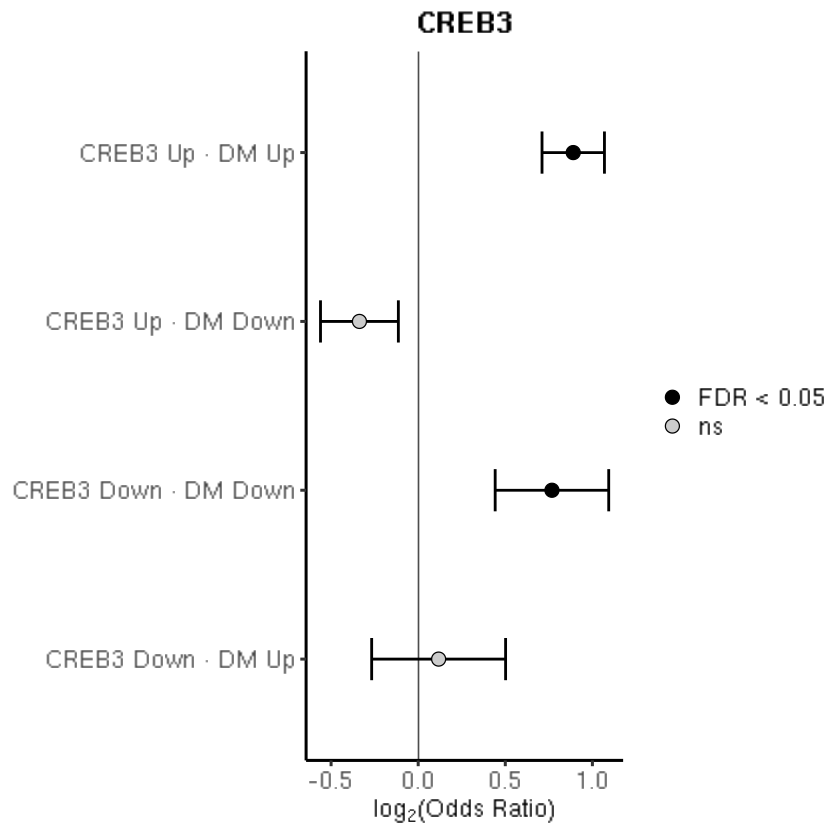

TF,TF_direction,DAMN_gene_set,n_tested_genes,n_TF_DE_genes,n_DAMN_genes,n_overlap_genes,odds_ratio_fisher,fisher_p_value,FDR,odds_ratio_plot,OR_plot_CI_lower,OR_plot_CI_upper
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CREB3,Up,DAMN Up,18700,2386,1799,362,1.8516528,1.208055e-20,4.832222e-20,1.8531575,1.6367142,2.0982239
CREB3,Up,DAMN Down,18700,2386,1847,195,0.7899171,9.989969e-01,9.989969e-01,0.7915381,0.6779623,0.9241408
CREB3,Down,DAMN Down,18700,604,1847,93,1.6955927,9.516136e-06,1.903227e-05,1.7026724,1.3584157,2.1341723
CREB3,Down,DAMN Up,18700,604,1799,62,1.0773540,3.122208e-01,4.162944e-01,1.0847396,0.8310173,1.4159271


TF,TF_direction,DAMN_gene_set,n_tested_genes,n_TF_DE_genes,n_DAMN_genes,n_overlap_genes,odds_ratio_fisher,fisher_p_value,FDR,odds_ratio_plot,OR_plot_CI_lower,OR_plot_CI_upper
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATF3,Up,DAMN Up,16355,251,1727,39,1.571027,8.885861e-03,1.184781e-02,1.587073,1.125876,2.237192
ATF3,Up,DAMN Down,16355,251,1768,50,2.082893,1.355777e-05,2.711554e-05,2.098080,1.535031,2.867654
ATF3,Down,DAMN Down,16355,237,1768,81,4.441165,3.254453e-22,1.301781e-21,4.453597,3.391485,5.848332
ATF3,Down,DAMN Up,16355,237,1727,27,1.090466,3.676014e-01,3.676014e-01,1.107705,0.742081,1.653472


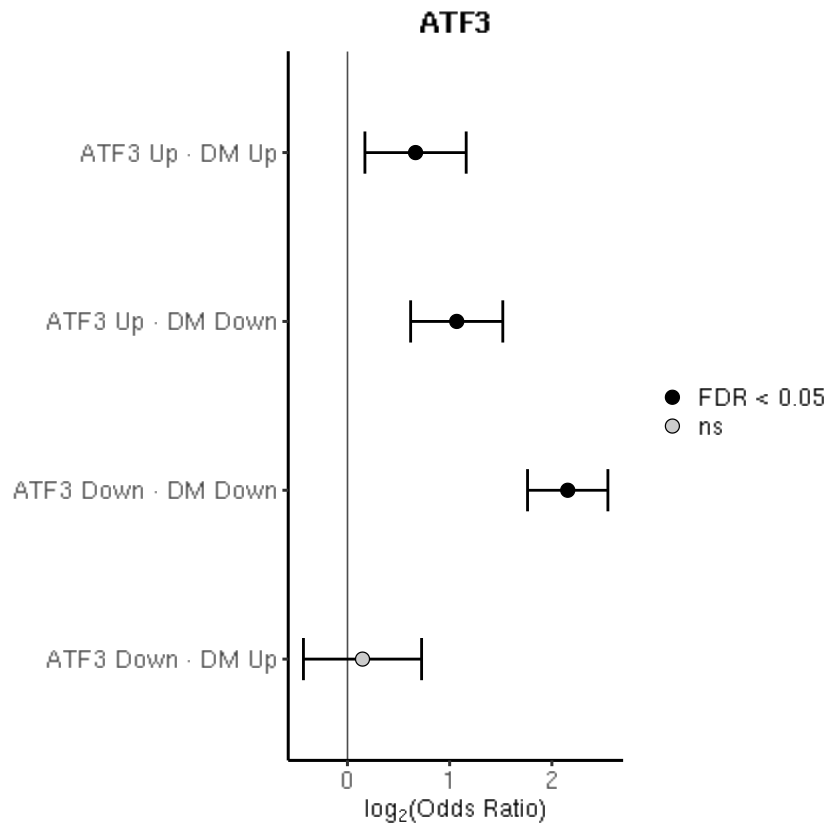

In [8]:
# ---------------------------
# Build TF up/down gene sets from DESeq2 results
# ---------------------------
make_tf_sets <- function(de_tbl, gene_col="X", padj_col="padj",
                         lfc_col="log2FoldChange",
                         padj_thresh=0.01, lfc_thresh=0) {

  de_tbl <- de_tbl %>%
    transmute(
      gene = as.character(.data[[gene_col]]),
      log2FC = as.numeric(.data[[lfc_col]]),
      padj = as.numeric(.data[[padj_col]])
    ) %>%
    filter(!is.na(gene), gene != "", !is.na(log2FC), is.finite(log2FC)) %>%
    distinct(gene, .keep_all = TRUE)

  up <- de_tbl %>%
    filter(!is.na(padj), padj < padj_thresh, log2FC >  lfc_thresh) %>%
    pull(gene) %>% unique()

  down <- de_tbl %>%
    filter(!is.na(padj), padj < padj_thresh, log2FC < -lfc_thresh) %>%
    pull(gene) %>% unique()

  list(
    TF_up_genes     = up,
    TF_down_genes   = down,
    universe_genes  = unique(de_tbl$gene)
  )
}

# ---------------------------
# Fisher enrichment with finite OR + CI for plotting
# ---------------------------
fisher_enrichment_or <- function(setA, setB, universe, alternative="greater") {

  setA <- intersect(unique(as.character(setA)), universe)
  setB <- intersect(unique(as.character(setB)), universe)
  universe <- unique(as.character(universe))

  a <- length(intersect(setA, setB))                 # overlap
  b <- length(setdiff(setB, setA))                   # TF-DE only
  c <- length(setdiff(setA, setB))                   # DAMN only
  d <- length(setdiff(universe, union(setA, setB)))  # neither

  mat <- matrix(c(a, b, c, d), nrow = 2, byrow = TRUE)
  ft  <- fisher.test(mat, alternative = alternative)

  # Plot-safe OR + CI (Haldane-Anscombe correction)
  aa <- a + 0.5; bb <- b + 0.5; cc <- c + 0.5; dd <- d + 0.5
  OR_plot <- (aa * dd) / (bb * cc)
  se_log  <- sqrt(1/aa + 1/bb + 1/cc + 1/dd)
  CI_lo   <- exp(log(OR_plot) - 1.96 * se_log)
  CI_hi   <- exp(log(OR_plot) + 1.96 * se_log)

  tibble(
    n_overlap_genes   = a,
    n_DAMN_genes      = length(setA),
    n_TF_DE_genes     = length(setB),
    n_tested_genes    = length(universe),

    odds_ratio_fisher = unname(ft$estimate),
    fisher_p_value    = ft$p.value,

    odds_ratio_plot   = OR_plot,
    OR_plot_CI_lower  = CI_lo,
    OR_plot_CI_upper  = CI_hi
  )
}

# ---------------------------
# Run 4 directional tests per TF
# ---------------------------
run_tf_damn_tests <- function(tf_name, tf_sets, damn_up_genes, damn_down_genes) {

  universe <- tf_sets$universe_genes

  bind_rows(
    fisher_enrichment_or(damn_up_genes,   tf_sets$TF_up_genes,   universe) %>%
      mutate(TF=tf_name, TF_direction="Up",   DAMN_gene_set="DAMN Up"),

    fisher_enrichment_or(damn_down_genes, tf_sets$TF_up_genes,   universe) %>%
      mutate(TF=tf_name, TF_direction="Up",   DAMN_gene_set="DAMN Down"),

    fisher_enrichment_or(damn_down_genes, tf_sets$TF_down_genes, universe) %>%
      mutate(TF=tf_name, TF_direction="Down", DAMN_gene_set="DAMN Down"),

    fisher_enrichment_or(damn_up_genes,   tf_sets$TF_down_genes, universe) %>%
      mutate(TF=tf_name, TF_direction="Down", DAMN_gene_set="DAMN Up")
  )
}

# ---------------------------
# DAMN gene sets
# ---------------------------
damn_up_genes   <- pathways$DAMN_up
damn_down_genes <- pathways$DAMN_down

# ---------------------------
# Build TF gene sets
# ---------------------------
sets_atf3  <- make_tf_sets(atf3_fixed,  gene_col="X", padj_thresh=0.01)
sets_creb3 <- make_tf_sets(creb3_fixed, gene_col="X", padj_thresh=0.01)

# ---------------------------
# Run enrichment tests + per-TF FDR
# ---------------------------
res_or <- bind_rows(
  run_tf_damn_tests("CREB3", sets_creb3, damn_up_genes, damn_down_genes),
  run_tf_damn_tests("ATF3",  sets_atf3,  damn_up_genes, damn_down_genes)
) %>%
  group_by(TF) %>%
  mutate(
    FDR = p.adjust(fisher_p_value, method = "BH")
  ) %>%
  ungroup() %>%
  mutate(
    log2_OR_plot     = log2(odds_ratio_plot),
    log2_OR_CI_lower = log2(OR_plot_CI_lower),
    log2_OR_CI_upper = log2(OR_plot_CI_upper)
  )

# ---------------------------
# Plot helper 
# ---------------------------
make_or_plot_tf <- function(res_or, tf_name, fdr_cutoff = 0.05) {

  df <- res_or %>%
    filter(TF == tf_name) %>%
    mutate(
      row_label = paste0(TF, " ", TF_direction, " \u00B7 ",
                         gsub("DAMN", "DM", DAMN_gene_set)),
      row_label = factor(
        row_label,
        levels = rev(c(
          paste0(tf_name, " Up \u00B7 DM Up"),
          paste0(tf_name, " Up \u00B7 DM Down"),
          paste0(tf_name, " Down \u00B7 DM Down"),
          paste0(tf_name, " Down \u00B7 DM Up")
        ))
      ),
      Sig = ifelse(!is.na(FDR) & FDR < fdr_cutoff, "FDR < 0.05", "ns"),
      Sig = factor(Sig, levels = c("FDR < 0.05", "ns"))
    )

  ggplot(df, aes(x = log2_OR_plot, y = row_label)) +
    geom_vline(xintercept = 0, linewidth = 0.35, color = "grey30") +
    geom_errorbarh(
      aes(xmin = log2_OR_CI_lower, xmax = log2_OR_CI_upper),
      height = 0.25,
      linewidth = 0.6,
      color = "black"
    ) +
    geom_point(
      aes(fill = Sig),
      shape = 21,
      size = 3.4,
      color = "black",
      stroke = 0.4
    ) +
    scale_fill_manual(
      values = c("FDR < 0.05" = "black", "ns" = "grey80"),
      guide = guide_legend(override.aes = list(color = "black"))
    ) +
    labs(
      title = tf_name,
      x = expression(log[2]*"(Odds Ratio)"),
      y = NULL,
      fill = NULL
    ) +
    theme_classic(base_size = 14) +
    theme(
      plot.title   = element_text(face = "bold", hjust = 0.5),
      axis.text    = element_text(size = 14),
      axis.title   = element_text(size = 14),
      legend.text  = element_text(size = 14),
      legend.title = element_text(size = 14),
      legend.position = "right"
    )
}

# Plots 
p_or_creb3 <- make_or_plot_tf(res_or, "CREB3")
p_or_atf3  <- make_or_plot_tf(res_or, "ATF3")

p_or_creb3
p_or_atf3

# ---------------------------
# Supplement tables 
# ---------------------------
supp_table_creb3 <- res_or %>%
  filter(TF == "CREB3") %>%
  mutate(
    row_order = factor(
      paste(TF_direction, DAMN_gene_set),
      levels = c("Up DAMN Up", "Up DAMN Down", "Down DAMN Down", "Down DAMN Up")
    )
  ) %>%
  arrange(row_order) %>%
  select(
    TF, TF_direction, DAMN_gene_set,
    n_tested_genes, n_TF_DE_genes, n_DAMN_genes, n_overlap_genes,
    odds_ratio_fisher, fisher_p_value, FDR,
    odds_ratio_plot, OR_plot_CI_lower, OR_plot_CI_upper
  )

supp_table_atf3 <- res_or %>%
  filter(TF == "ATF3") %>%
  mutate(
    row_order = factor(
      paste(TF_direction, DAMN_gene_set),
      levels = c("Up DAMN Up", "Up DAMN Down", "Down DAMN Down", "Down DAMN Up")
    )
  ) %>%
  arrange(row_order) %>%
  select(
    TF, TF_direction, DAMN_gene_set,
    n_tested_genes, n_TF_DE_genes, n_DAMN_genes, n_overlap_genes,
    odds_ratio_fisher, fisher_p_value, FDR,
    odds_ratio_plot, OR_plot_CI_lower, OR_plot_CI_upper
  )

supp_table_creb3
supp_table_atf3

## GO enrichment plots

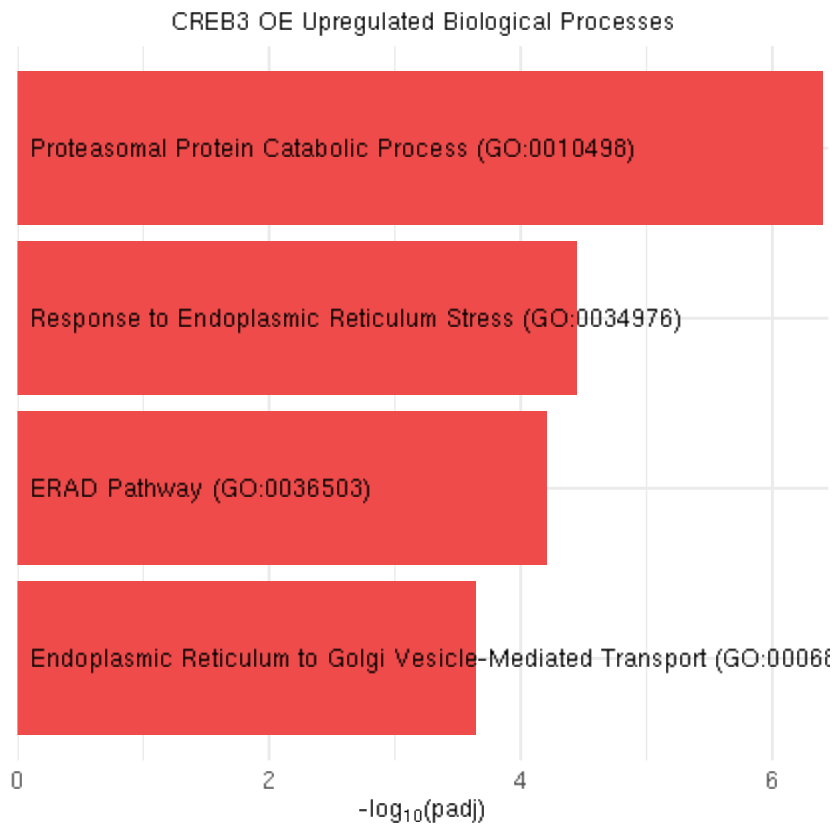

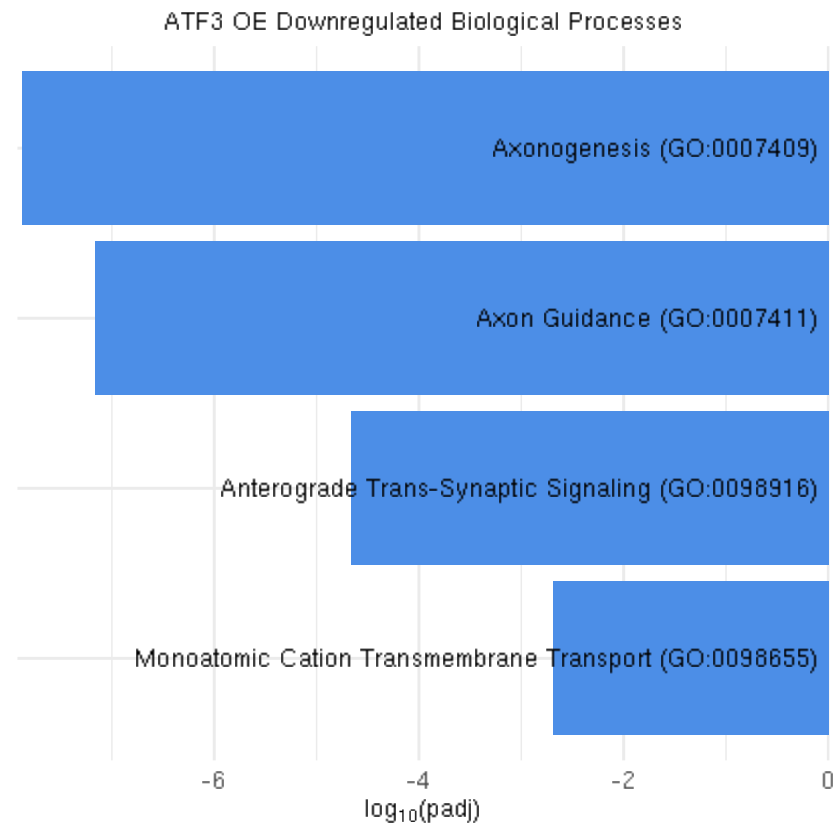

In [9]:
creb3_up_GO <- read.csv(paste0(save_dir, "GO/CREB3_DAMN_Up_LeadingGenes_GO_Biological_Process_2025_table.csv"))
atf3_down_GO <- read.csv(paste0(save_dir, "GO/ATF3_DAMN_Down_LeadingGenes_GO_Biological_Process_2025_table.csv"))

light_firebrick3  <- lighten("firebrick3",  0.2)
light_dodgerblue3 <- lighten("dodgerblue3", 0.2)

up_terms <- c("Response to Endoplasmic Reticulum Stress (GO:0034976)",
              "ERAD Pathway (GO:0036503)",
              "Proteasomal Protein Catabolic Process (GO:0010498)",
              "Endoplasmic Reticulum to Golgi Vesicle-Mediated Transport (GO:0006888)")

down_terms <- c("Axonogenesis (GO:0007409)",
              "Axon Guidance (GO:0007411)",
              "Anterograde Trans-Synaptic Signaling (GO:0098916)",
              "Monoatomic Cation Transmembrane Transport (GO:0098655)")

# Get selected, significant terms
up_terms_df <- creb3_up_GO %>%
  dplyr::filter(Term %in% up_terms)

up_terms_df$Term <- fct_reorder(up_terms_df$Term, up_terms_df$Adjusted.P.value, .desc = TRUE)

# Get selected, significant terms
down_terms_df <- atf3_down_GO %>%
  dplyr::filter(Term %in% down_terms)

down_terms_df$Term <- fct_reorder(down_terms_df$Term, down_terms_df$Adjusted.P.value, .desc = TRUE)

creb3_up_GO_plot <- ggplot(up_terms_df, aes(x = -log10(Adjusted.P.value), y = Term)) +
  geom_col(fill = light_firebrick3) +
  geom_text(aes(x = 0.1, y = Term, label = Term),
            hjust = 0, vjust = 0.5, color = "black",
            inherit.aes = FALSE, size = 5) +  
  scale_x_continuous(expand = expansion(add = c(0, 0.05))) +
  ggtitle("CREB3 OE Upregulated Biological Processes") +
  labs(x = expression("-log"[10]*"(padj)"), y = NULL) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.y    = element_blank(),
    plot.title     = element_text(hjust = 0.5, size = 14),  # center title
    axis.title.x   = element_text(size = 14),
    axis.text.x    = element_text(size = 14)
  )

creb3_up_GO_plot

atf3_down_GO_plot <- ggplot(down_terms_df, aes(x = log10(Adjusted.P.value), y = Term)) +
  geom_col(fill = light_dodgerblue3) +
  geom_text(
    aes(x = -0.1, y = Term, label = Term),
    hjust = 1, vjust = 0.5, color = "black",
    inherit.aes = FALSE,
    size = 5  
  ) +
  scale_x_continuous(expand = expansion(add = c(0.05, 0))) +
  ggtitle("ATF3 OE Downregulated Biological Processes") +
  labs(x = expression("log"[10]*"(padj)"), y = NULL) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.y  = element_blank(),
    axis.text.x  = element_text(size = 14),
    axis.title.x = element_text(size = 14),
    plot.title   = element_text(hjust = 0.5, size = 14)
  )

atf3_down_GO_plot